In [32]:
import random
import pandas as pd
from model_test_CAM import DyMoTree
from utils import get_metric,seed_all
seed_all(1, deterministic=True)
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scLT/Weinreb/BiTree/desc246',
                 task='Larry',
                 n_neighbor=50,
                 device='cuda') 
seeds = [392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]#[random.randint(0, 2**10 - 1) for _ in range(run)]
#[392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]
task_list = ['DMT only','DMT+s1','DMT+s2','DMT+s1+s2']
metric_dict = {}
for task in task_list:
    seed_all(seeds[14], deterministic=True)
    metric = dmt.test(task=task,
                intra=0.5,inter=0.5,W=0.,
                pre_lr=1e-5,
                pre_iter=200,
                lr=1e-4,
                n_iter=200)   
    metric['task'] = task
    metric_dict[task] = metric  

[2025-11-07 13:48:39] loading node data for HSPC
[2025-11-07 13:48:41] loading node data for Monocyte
[2025-11-07 13:48:42] loading node data for Neutrophil
[2025-11-07 13:48:43] calculate shortest distance for HSPC with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    1.8s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    1.8s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:    2.1s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:    2.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    2.2s finished


[2025-11-07 13:48:46] loading edge data for HSPC
:: DyMoTree Training::


Iter: 200/200 : 100%|██████████████████████████████████| 200/200 [00:41<00:00,  4.80it/s, loss=1.11]


:: Stage1 Pre-training -- intra-graph::
:: Do pre-train Graph encoder for HSPC::


...

100%|█████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.67it/s, loss=0.626]


:: Stage2 Pre-training -- lineage-graph::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:51<00:00,  3.90it/s, loss=0.782]


:: DyMoTree Training::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:41<00:00,  4.80it/s, loss=0.771]


In [33]:
metric = pd.concat([metric_dict[t] for t in metric_dict.keys()],axis=0)
metric

,iter,Loss,AUROC,Accuracy,F1-score,Pearson,Spearman,task
0,0,2.6566193103790283,0.518674,0.513585,0.513491,0.039849,0.021517,DMT only
1,10,1.9208526611328125,0.517236,0.511597,0.511528,0.022532,0.019282,DMT only
2,20,1.7940833568572998,0.518937,0.514248,0.514163,-0.010213,0.022059,DMT only
3,30,1.7416245937347412,0.521781,0.515573,0.515519,0.011540,0.027157,DMT only
4,40,1.6678087711334229,0.521194,0.518887,0.518793,0.032948,0.026971,DMT only
...,...,...,...,...,...,...,...,...
15,150,0.7855747938156128,0.491493,0.495693,0.490660,-0.015599,-0.015888,DMT+s1+s2
16,160,0.7818982601165771,0.493263,0.497018,0.491584,0.023803,-0.013468,DMT+s1+s2
17,170,0.7789907455444336,0.495342,0.500331,0.494863,0.030685,-0.010367,DMT+s1+s2
18,180,0.7753970623016357,0.495838,0.501657,0.495773,-0.022885,-0.010971,DMT+s1+s2


In [34]:
metric.to_csv('./Fig2/6.Larry.DMT.CAM.Ablation.exp/PreTrain.NoCAM.res.csv')

In [35]:
import pandas as pd
metric = pd.read_csv('./Fig2/6.Larry.DMT.CAM.Ablation.exp/PreTrain.NoCAM.res.csv')

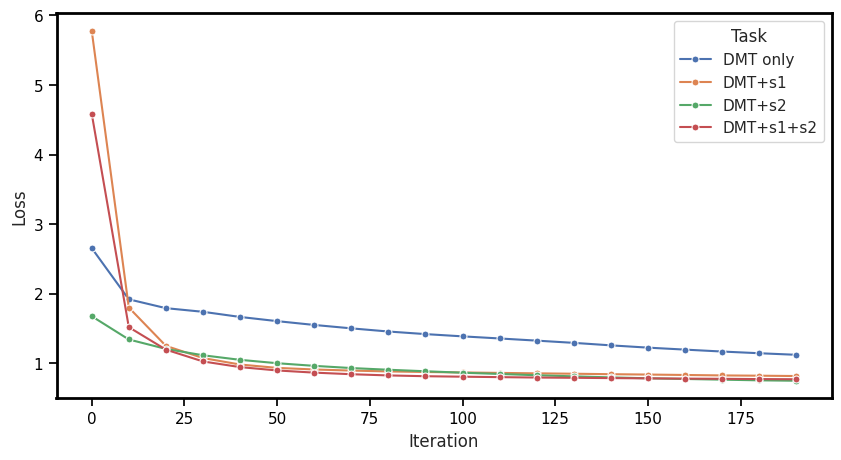

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
m = 'Loss'

sns.set_theme(style="ticks")
plt.figure(figsize=(10, 5))
plot = sns.lineplot(
    data=metric,         
    x='iter',        
    y=m,       
    hue='task',      # 仅通过 'hue' (颜色) 来区分
    marker='o',      # <-- (单数) 设置样式为实心圆
    # ---  这是你要求的新修改  ---
    linewidth=1.5,   # <-- 线宽调小 (原为 2.5)
    markersize=5,   # <-- 点调大 (新增此参数)
    # ---------------------------
)

plot.set_xlabel('Iteration', fontsize=12)
plot.set_ylabel(m, fontsize=12)
plt.legend(title='Task')

for spine_name in ['top', 'bottom', 'left', 'right']:
    spine = plot.spines[spine_name]
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plot.tick_params(axis='both', colors='black')
plt.savefig(f"./Fig2/6.Larry.DMT.CAM.Ablation.exp/{m}_linepoint.plot.pdf",bbox_inches='tight')
plt.show()

In [75]:
import random
import pandas as pd
from model_test_CAM import DyMoTree
from utils import get_metric,seed_all
seed_all(1, deterministic=True)

dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scLT/Weinreb/BiTree/desc246',
                 task='Larry',
                 n_neighbor=50,
                 device='cuda') 
task_list = ['DMT only','DMT+s1','DMT+s2','DMT+s1+s2']
metric = pd.DataFrame(columns=['Task','AUROC','Accuracy','F1-score','Pearson','Spearman'])
seeds = [392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]#[random.randint(0, 2**10 - 1) for _ in range(run)]
#[392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]
for task in task_list:
    for i in seeds:
        seed_all(i, deterministic=True)
        _ = dmt.test(task=task,
                intra=0.5,inter=0.5,W=0.,
                pre_lr=1e-5,
                pre_iter=200,
                lr=1e-4,
                n_iter=200)  
        dmt.get_fate_sapce()
        metric.loc[len(metric)] = [task]+get_metric(dmt,'fate')
metric.to_csv('./Fig2/6.Larry.DMT.CAM.Ablation.exp/NoCAM.PreTrain.res.csv')

[2025-11-07 14:05:12] loading node data for HSPC
[2025-11-07 14:05:13] loading node data for Monocyte
[2025-11-07 14:05:15] loading node data for Neutrophil
[2025-11-07 14:05:16] calculate shortest distance for HSPC with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    1.7s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    1.8s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:    2.1s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:    2.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    2.2s finished


[2025-11-07 14:05:19] loading edge data for HSPC
:: DyMoTree Training::


Iter: 200/200 : 100%|██████████████████████████████████| 200/200 [00:43<00:00,  4.64it/s, loss=1.11]


[2025-11-07 14:06:03] get fate space of HSPC
:: DyMoTree Training::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:50<00:00,  3.94it/s, loss=0.781]


:: DyMoTree Training::


Iter: 200/200 : 100%|█████████████████████████████████| 200/200 [00:42<00:00,  4.74it/s, loss=0.764]


[2025-11-07 16:01:41] get fate space of HSPC


In [76]:
CAM_res = pd.read_csv('./Fig2/1.Larry.DMT.bench.result/PreTrain.bench.csv')
CAM_res = CAM_res.loc[0:59]
CAM_res_ = pd.read_csv('./Fig2/1.Larry.DMT.bench.result/PreTrain.s2.exp.csv')
CAM_res = pd.concat([CAM_res,CAM_res_],axis=0)
CAM_res.loc[CAM_res['Task']=='DMT+s1+s2:lr=1e-5','Task'] = 'DMT+s1+s2'
CAM_res['CAM'] = 'Cross attention matrix'

No_CAM_res = pd.read_csv('./Fig2/6.Larry.DMT.CAM.Ablation.exp/NoCAM.PreTrain.res.csv')
No_CAM_res['CAM'] = 'Weight matrix'

df_metrics = pd.concat([CAM_res,No_CAM_res],axis=0)

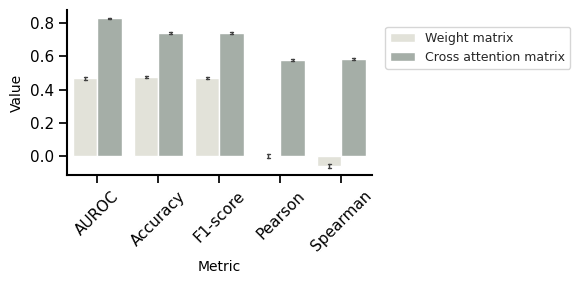

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
task_colors = {
    'DyMoTree': '#d7cae4',  # 柔和的蓝色
    'WOT': '#fcd5b4',  # 温暖的橙色
    'FateID': '#e8e7bb',   # 清新的绿色
    'CellRank': '#d5ebf0',   # 清新的绿色
    'Palantir': '#c6dfb8',   # 清新的绿色
    'Prior': '#bccbe8',   # 清新的绿色
    'Cross attention matrix': '#A4AFA6',
    'Weight matrix': '#E4E4D7'
    # 如果有更多task，在这里继续添加
}
t = 'DMT+s1+s2'
df = df_metrics[df_metrics['Task'].isin([t])][['AUROC', 'Accuracy','F1-score' , 'Pearson','Spearman','CAM']].copy()
#df = df_metrics[df_metrics['task'].isin(['DyMoTree','Prior'])][['task','F1-score', 'Accuracy', 'AUROC', 'Pearson','Spearman']].copy()
df_long=pd.melt(df, 
                    id_vars='CAM', 
                    value_vars=['AUROC', 'Accuracy','F1-score' , 'Pearson','Spearman'],
                    var_name='metric', 
                    value_name='value')

# --- 3. 设置绘图风格和创建画布 ---
# 'ticks' 风格会移除背景网格线，并添加坐标轴刻度线
sns.set_theme(style="ticks") 
fig, ax = plt.subplots(figsize=(4, 3)) # 使用 ax 对象进行更精细的控制

# --- 4. 绘制柱状图 ---
sns.barplot(
    data=df_long, 
    x='metric', 
    y='value', 
    hue='CAM',
    capsize=0.1,
    hue_order=['Weight matrix','Cross attention matrix'],
    err_kws={'linewidth': 1},
    palette=task_colors,# 应用我们自定义的颜色
    ax=ax               # 在我们创建的 ax 上绘图
)

# --- 5. 精细调整外观 ---
# 5.1 去掉顶部和右侧的边框线 (可选，但更美观)
sns.despine()

# 5.2 将坐标轴边框变黑并加粗 (满足“边框变黑”的需求)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

# 5.3 确保刻度线也是黑色的
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# --- 6. 添加标题和标签 ---
#plt.title('Mean AUROC by Task (with Standard Deviation Error Bars)', fontsize=8, color='black')
plt.xlabel('Metric', fontsize=10, color='black')
plt.ylabel('Value', fontsize=10, color='black')
plt.xticks(rotation=45) # 任务名不长的话，无需旋转
plt.tight_layout()
plt. legend (bbox_to_anchor=( 1.65 , 0.9), loc='upper right', borderaxespad= 0 ,fontsize= '9')
# --- 7. 保存或显示图形 ---
plt.savefig(f"./Fig2/6.Larry.DMT.CAM.Ablation.exp/CAM.Ablation.{t}.png",bbox_inches='tight')
plt.show()